In [41]:
import pandas as pd
import numpy as np

In [42]:
df = pd.read_csv('AB_NYC_2019.csv')

In [43]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [44]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [45]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical Columns: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


In [46]:
# List of columns to drop
cols_to_drop = ['id', 'host_id', 'host_name']

# Drop the columns (inplace=True modifies the DataFrame directly)
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Display remaining columns
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [47]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical Columns: ['name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


In [48]:
# Calculate total missing values per column
missing_count = df.isnull().sum()

# Calculate percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine results into a clean DataFrame
missing_info = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percentage.round(2)
})

# Filter to show only columns that have missing values
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(missing_info)

                   Missing Count  Percentage (%)
last_review                10052           20.56
reviews_per_month          10052           20.56
name                          16            0.03


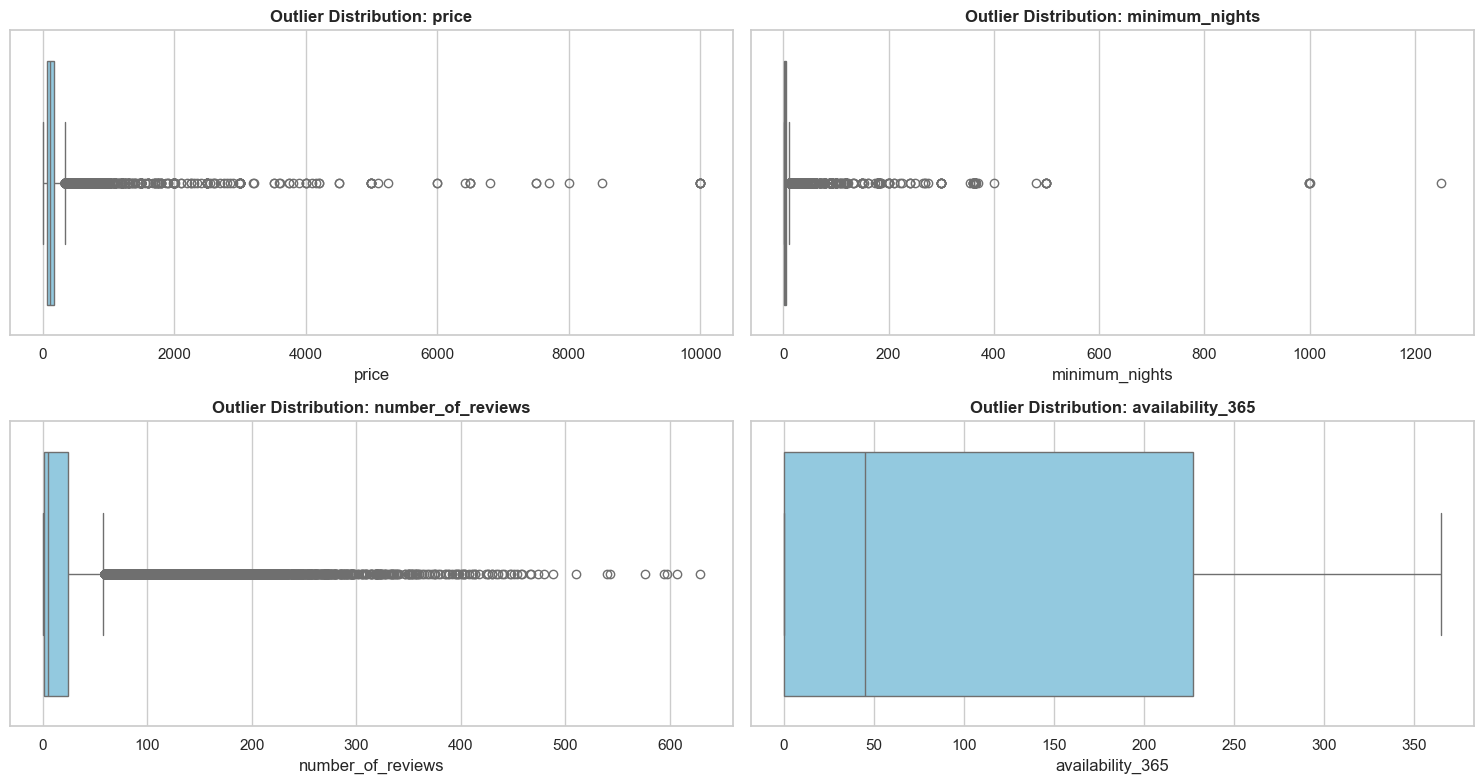

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Define target columns prone to extreme outliers
outlier_cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']

# Create subplots for Boxplots
plt.figure(figsize=(15, 8))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outlier Distribution: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [111]:
def count_outliers_iqr(df, cols):
    outlier_summary = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': round(len(outliers) / len(df) * 100, 2),
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2)
        }
    return pd.DataFrame(outlier_summary).T

outlier_cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']
outlier_report = count_outliers_iqr(df, outlier_cols)
print(outlier_report)

                    count  percentage  lower_bound  upper_bound
price              2971.0        6.08        -90.0        334.0
minimum_nights     6606.0       13.52         -5.0         11.0
number_of_reviews  6021.0       12.32        -33.5         58.5
availability_365      0.0        0.00       -340.5        567.5


In [50]:
# Drop rows where 'name' is missing
df.dropna(subset=['name'], inplace=True)

# Verify that there are no missing values left in 'name'
print("Missing values in 'name':", df['name'].isnull().sum())
print("Remaining rows in dataset:", len(df))

Missing values in 'name': 0
Remaining rows in dataset: 48879


In [51]:
# Calculate total missing values per column
missing_count = df.isnull().sum()

# Calculate percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine results into a clean DataFrame
missing_info = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percentage.round(2)
})

# Filter to show only columns that have missing values
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(missing_info)

                   Missing Count  Percentage (%)
last_review                10042           20.54
reviews_per_month          10042           20.54


In [52]:
# 1. Convert 'last_review' to datetime format
df['last_review'] = pd.to_datetime(df['last_review'])

# 2. Find the reference date (most recent date in the dataset)
max_date = df['last_review'].max()

# 3. Calculate days elapsed since the last review
df['days_since_last_review'] = (max_date - df['last_review']).dt.days

# 4. Fill missing values (listings with 0 reviews) with a large number or 0
# Filling with -1 or a value larger than max days flags them as "never reviewed"
df['days_since_last_review'].fillna(-1, inplace=True)

# 5. Drop the original date column
df.drop(columns=['last_review'], inplace=True)

C:\Users\patod\AppData\Local\Temp\ipykernel_18056\4039228065.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['days_since_last_review'].fillna(-1, inplace=True)


In [53]:
# Display the first 5 rows of the new numerical feature
print(df[['days_since_last_review']].head())

   days_since_last_review
0                   262.0
1                    48.0
2                    -1.0
3                     3.0
4                   231.0


In [54]:
import numpy as np

# Replace -1 values with NaN (empty)
df['days_since_last_review'] = df['days_since_last_review'].replace(-1, np.nan)

# Verify the missing value count
print("Null count in 'days_since_last_review':", df['days_since_last_review'].isnull().sum())
print(df[['days_since_last_review']].head())

Null count in 'days_since_last_review': 10042
   days_since_last_review
0                   262.0
1                    48.0
2                     NaN
3                     3.0
4                   231.0


In [112]:
# Remove extreme outliers above the 99th percentile (approx $800-$1000)
q_99 = df['price'].quantile(0.99)
print(f"99th percentile price: ${q_99:.2f}")
print(f"Rows before filtering: {len(df)}")

df = df[df['price'] <= q_99].copy()

print(f"Rows after filtering: {len(df)}")

99th percentile price: $799.00
Rows before filtering: 48879
Rows after filtering: 48405


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['price'])
y = df['price']

# 2. Handle missing text values before splitting
X['name'] = X['name'].fillna('')

# 3. Apply domain logic: Missing reviews_per_month means 0 reviews per month
X['reviews_per_month'] = X['reviews_per_month'].fillna(0)

# 4. Split into Train and Test sets FIRST (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Impute NaNs AFTER splitting
X_train['reviews_per_month'] = X_train['reviews_per_month'].fillna(0)
X_test['reviews_per_month'] = X_test['reviews_per_month'].fillna(0)

In [114]:
# 1. Define feature groups
text_col = 'name'
recency_col = ['days_since_last_review']
num_cols = ['latitude', 'longitude', 'minimum_nights', 
            'number_of_reviews', 'reviews_per_month', 
            'calculated_host_listings_count', 'availability_365']
cat_cols = ['neighbourhood_group', 'room_type']

In [115]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

In [116]:
def cap_minimum_nights(df_num):
    df_copy = df_num.copy()
    df_copy['minimum_nights'] = df_copy['minimum_nights'].clip(upper=30)
    return df_copy

In [117]:

# 2. Build ColumnTransformer using recency_col
preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            CountVectorizer(stop_words='english', max_features=30),
            text_col,
        ),
        (
            'recency',
            Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
                ('scaler', StandardScaler()),
            ]),
            recency_col,
        ),  # <--- using recency_col here
        (
            'num',
            Pipeline([
                 ('cap', FunctionTransformer(cap_minimum_nights)),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            num_cols,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                (
                    'encoder',
                    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                ),
            ]),
            cat_cols,
        ),
    ]
)

In [118]:
X_train_transformed = preprocessor.fit_transform(X_train)
print("Shape after preprocessing:", X_train_transformed.shape)

Shape after preprocessing: (38724, 46)


In [119]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Build the full pipeline: preprocessing + model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 2. Fit on training data
lr_pipeline.fit(X_train, y_train)

# 3. Predict on train and test sets
y_train_pred = lr_pipeline.predict(X_train)
y_test_pred = lr_pipeline.predict(X_test)

# 4. Evaluate
def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.3f}")

evaluate(y_train, y_train_pred, "Train")
evaluate(y_test, y_test_pred, "Test")

Train -> RMSE: 79.63, MAE: 50.51, R²: 0.408
Test -> RMSE: 79.88, MAE: 50.43, R²: 0.419


In [142]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=5000))
])

param_grid_elastic = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    elastic_pipeline, param_grid_elastic, cv=5, scoring='r2', n_jobs=-1
)
elastic_search.fit(X_train, np.log1p(y_train))

print("Best params:", elastic_search.best_params_)
print("Best CV R²:", elastic_search.best_score_)

Best params: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.1}
Best CV R²: 0.56878706129361


In [120]:
lr_pipeline_log = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit on log1p(price)
lr_pipeline_log.fit(X_train, np.log1p(y_train))

# Predict and invert the log transform
y_train_pred_log = np.expm1(lr_pipeline_log.predict(X_train))
y_test_pred_log = np.expm1(lr_pipeline_log.predict(X_test))

evaluate(y_train, y_train_pred_log, "Train (log-target)")
evaluate(y_test, y_test_pred_log, "Test (log-target)")

Train (log-target) -> RMSE: 80.07, MAE: 45.72, R²: 0.402
Test (log-target) -> RMSE: 80.39, MAE: 45.72, R²: 0.412


now for random forest

In [133]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, max_depth=16, random_state=42, n_jobs=-1))
])

# Fit on log1p(price)
rf_pipeline.fit(X_train, np.log1p(y_train))

# Predict and invert
y_train_pred_rf = np.expm1(rf_pipeline.predict(X_train))
y_test_pred_rf = np.expm1(rf_pipeline.predict(X_test))

evaluate(y_train, y_train_pred_rf, "Train (RF, log-target)")
evaluate(y_test, y_test_pred_rf, "Test (RF, log-target)")

Train (RF, log-target) -> RMSE: 50.93, MAE: 28.06, R²: 0.758
Test (RF, log-target) -> RMSE: 71.86, MAE: 40.53, R²: 0.530


In [124]:
# Option A: max_feat4ures='sqrt'
rf_sqrt = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        # min_samples_leaf=20,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_sqrt.fit(X_train, np.log1p(y_train))
y_train_pred_sqrt = np.expm1(rf_sqrt.predict(X_train))
y_test_pred_sqrt = np.expm1(rf_sqrt.predict(X_test))

evaluate(y_train, y_train_pred_sqrt, "Train (RF, max_features='sqrt')")
evaluate(y_test, y_test_pred_sqrt, "Test (RF, max_features='sqrt')")

# Option B: max_features=0.3
rf_03 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        # min_samples_leaf=20,
        max_features=0.3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_03.fit(X_train, np.log1p(y_train))
y_train_pred_03 = np.expm1(rf_03.predict(X_train))
y_test_pred_03 = np.expm1(rf_03.predict(X_test))

evaluate(y_train, y_train_pred_03, "Train (RF, max_features=0.3)")
evaluate(y_test, y_test_pred_03, "Test (RF, max_features=0.3)")

Train (RF, max_features='sqrt') -> RMSE: 78.04, MAE: 43.11, R²: 0.432
Test (RF, max_features='sqrt') -> RMSE: 80.08, MAE: 44.18, R²: 0.416
Train (RF, max_features=0.3) -> RMSE: 73.94, MAE: 41.08, R²: 0.490
Test (RF, max_features=0.3) -> RMSE: 76.81, MAE: 42.68, R²: 0.463


In [132]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__max_depth': [12, 14, 16],
    # 'regressor__min_samples_leaf': [5, 10, 20],
    'regressor__n_estimators': [200, 300]
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, np.log1p(y_train))

print("Best params:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best params: {'regressor__max_depth': 16, 'regressor__n_estimators': 300}
Best CV R²: 0.6492190677913946


In [137]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'regressor__n_estimators': [200, 300],
    'regressor__max_depth': randint(8, 18),
    'regressor__min_samples_leaf': randint(5, 25),
    'regressor__max_features': ['sqrt',0.3 , 0.5, None]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,        # down from 30
    cv=2,             # down from 3
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, np.log1p(y_train))

print("Best params:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

best_rf = random_search.best_estimator_
y_train_pred_best = np.expm1(best_rf.predict(X_train))
y_test_pred_best = np.expm1(best_rf.predict(X_test))

evaluate(y_train, y_train_pred_best, "Train (RF, random search)")
evaluate(y_test, y_test_pred_best, "Test (RF, random search)")

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best params: {'regressor__max_depth': 15, 'regressor__max_features': 0.5, 'regressor__min_samples_leaf': 6, 'regressor__n_estimators': 300}
Best CV R²: 0.645388571625631
Train (RF, random search) -> RMSE: 64.56, MAE: 34.96, R²: 0.611
Test (RF, random search) -> RMSE: 72.91, MAE: 40.83, R²: 0.516


In [ ]:
# this is the same one from above
# using it again just to show that it is the best one 

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, max_depth=16, random_state=42, n_jobs=-1))
])

# Fit on log1p(price)
rf_pipeline.fit(X_train, np.log1p(y_train))

# Predict and invert
y_train_pred_rf = np.expm1(rf_pipeline.predict(X_train))
y_test_pred_rf = np.expm1(rf_pipeline.predict(X_test))

evaluate(y_train, y_train_pred_rf, "Train (RF, log-target)")
evaluate(y_test, y_test_pred_rf, "Test (RF, log-target)")

Train (RF, log-target) -> RMSE: 50.92, MAE: 28.06, R²: 0.758
Test (RF, log-target) -> RMSE: 71.90, MAE: 40.55, R²: 0.529


In [144]:
import joblib

# Save the entire fitted pipeline (preprocessing + model together)
joblib.dump(rf_pipeline, 'airbnb_price_model.pkl')

print("Model saved as airbnb_price_model.pkl")

Model saved as airbnb_price_model.pkl


In [146]:
# Quick sanity check
loaded_model = joblib.load('airbnb_price_model.pkl')
sample_pred = np.expm1(loaded_model.predict(X_test.iloc[[0]]))
print("Sample prediction:", sample_pred)
print("Actual price:", y_test.iloc[0])

Sample prediction: [227.87358018]
Actual price: 162


In [150]:
sample = X_test.iloc[:10]
preds = np.expm1(loaded_model.predict(sample))

comparison = pd.DataFrame({
    'Predicted': preds.round(2),
    'Actual': y_test.iloc[:10].values
})
print(comparison)

   Predicted  Actual
0     227.87     162
1      50.97      54
2     595.39     649
3      74.87      75
4     141.06     165
5     142.67     104
6     175.22     189
7     249.27     190
8      61.14      42
9     236.12     140
